#Mini-Project: Predicting Heart Disease Using Logistic Regression


In [57]:
import os
import pandas as pd

files = os.listdir('.')
print("Files:", files)

#Find the heart disease dataset file path
heart_file = [f for f in files if 'heart' in f.lower()]
print("Heart file:", heart_file)

if heart_file:
  df = pd.read_csv(heart_file[0])
  print(df.info())
  print(df.head())


Files: ['.config', 'heart_disease_uci.csv', 'sample_data']
Heart file: ['heart_disease_uci.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None
   id  age     sex    datas

In [58]:
import numpy as np

print("Target variable 'num' value counts:")
print(df['num'].value_counts())

#Convert num to binary (0 = no heart disease, 1 = heart disease)
df['target'] = (df['num'] > 0).astype(int)
print("\nBinary target distribution:")
print(df['target'].value_counts(normalize=True))

print("\nMissing values percentage:")
print(df.isnull().mean() * 100)


Target variable 'num' value counts:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Binary target distribution:
target
1    0.553261
0    0.446739
Name: proportion, dtype: float64

Missing values percentage:
id           0.000000
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
trestbps     6.413043
chol         3.260870
fbs          9.782609
restecg      0.217391
thalch       5.978261
exang        5.978261
oldpeak      6.739130
slope       33.586957
ca          66.413043
thal        52.826087
num          0.000000
target       0.000000
dtype: float64


In [59]:
print(df.dtypes)
print("\nUnique values of categorical features:")
categorical_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
  print(f"--- {col} ---")
  print(df[col].value_counts(dropna=False))


id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
target        int64
dtype: object

Unique values of categorical features:
--- sex ---
sex
Male      726
Female    194
Name: count, dtype: int64
--- dataset ---
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64
--- cp ---
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64
--- fbs ---
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64
--- restecg ---
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64
--- exang ---
exang
False    528
True     3

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#Load data
df = pd.read_csv('heart_disease_uci.csv')

#1. Target creation & dropping unnecessary columns
df['target'] = (df['num'] > 0).astype(int)
X = df.drop(columns=['id', 'dataset', 'num', 'target'])
y = df['target']

#Identify feature types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

#Define Preprocessing Pipelines
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Fit pipeline on training data and transform both
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

#Model Training
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_prep, y_train)

#Evaluation

y_pred = model.predict(X_test_prep)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1 Score:   {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Numerical columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Accuracy:   0.8424
Precision:  0.8411
Recall:     0.8824
F1 Score:   0.8612

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184

Confusion Matrix:
 [[65 17]
 [12 90]]


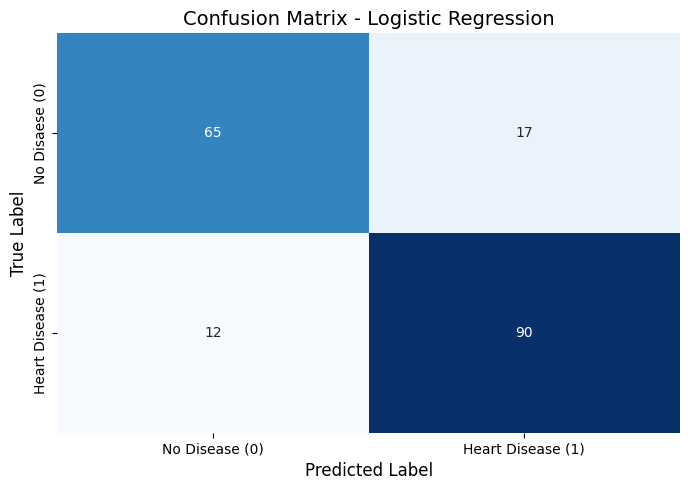

In [61]:
#Heatmap Visualization

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Disease (0)', 'Heart Disease (1)'],
    yticklabels=['No Disaese (0)', 'Heart Disease (1)'],
    cbar=False
)
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()


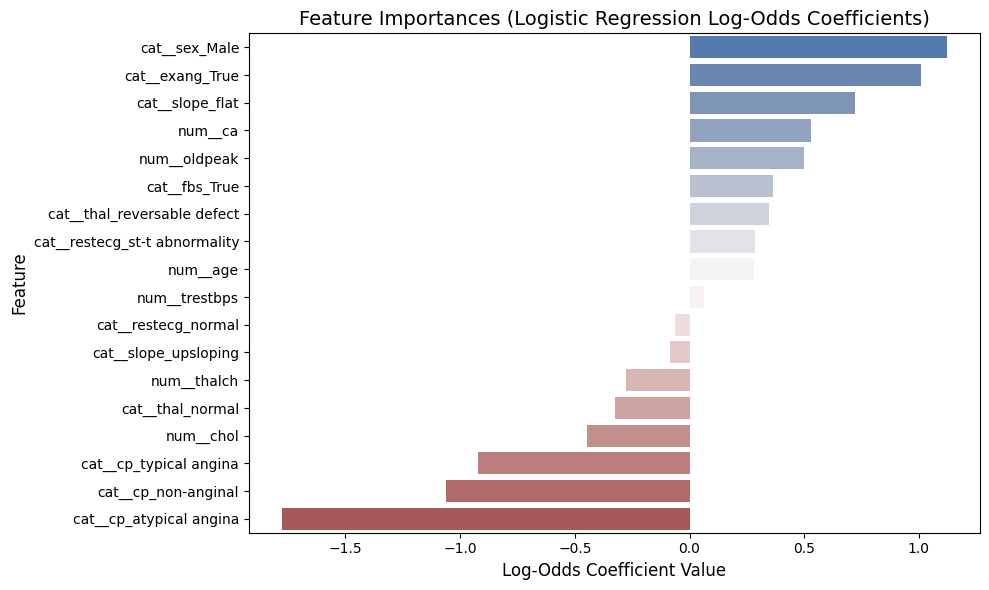

In [67]:
all_features = preprocessor.get_feature_names_out()
coefficients = model.coef_[0]

# Build DataFrame
coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', hue='Feature', palette='vlag', legend=False)
plt.title('Feature Importances (Logistic Regression Log-Odds Coefficients)', fontsize=14)
plt.xlabel('Log-Odds Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()